##  CD_PSI avec taux hétérogènes réels (λ, μ issus du dataset Brexit)

On reprend le **même sous-graphe Top-100** que précédemment, mais on remplace les taux uniformes `λ=μ=1` par les **vrais taux estimés depuis les données** :
- `λ(n)` = nombre de tweets originaux du nœud n
- `μ(n)` = nombre de retweets effectués par le nœud n

Cela permet de tester le ψ-score dans le **cas hétérogène**, qui est son véritable apport par rapport au PageRank classique.

In [25]:
import json
import numpy as np
import networkx as nx
import data as dt
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from tqdm import tqdm
from psi_score import PsiScore
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from networkx.algorithms.community import modularity as nx_modularity

In [7]:
bre = dt.BrexitFollowers(root="data/Brexit")
graph_directed = bre.to_networkx()   
graph = graph_directed.to_undirected()  

print(f"Graphe complet : {bre.n} nœuds, {bre.m} arêtes")
print(f"Opinions disponibles : {set(nx.get_node_attributes(graph, 'max_opinion').values())}")

Graphe complet : 7589 nœuds, 532459 arêtes
Opinions disponibles : {'remain', 'leave', 'neutral'}


### Étape 1 - Calcul des λ et μ depuis items.json

In [8]:
def get_lambdas_mus(root, edge_list, num_nodes):
    """
    Calcule les taux de publication (lambda) et de repartage (mu)
    pour chaque nœud, à partir des chaînes de retweets dans items.json.
    - lambda[n] = nombre de tweets originaux attribués au nœud n
    - mu[n]     = nombre de retweets effectués par le nœud n
    """
    with open(f"{root}/items.json", "r") as f:
        items_dict = json.load(f)

    # In-degree (nombre de followers) pour chaque nœud
    in_degree = {i: 0 for i in range(num_nodes)}
    for e in edge_list:
        in_degree[e[1]] += 1

    num_tweets   = {}
    num_retweets = {}

    for i in tqdm(items_dict, desc="Calcul λ/μ"):
        # L'auteur = nœud avec le plus de followers dans la chaîne
        author = max(
            items_dict[i]["retweet_chain"],
            key=lambda x: in_degree[int(x)]
        )
        author = int(author)
        num_tweets[author] = num_tweets.get(author, 0) + 1

        for u in items_dict[i]["retweet_chain"]:
            u = int(u)
            if u != author:
                num_retweets[u] = num_retweets.get(u, 0) + 1

    lambdas = [num_tweets.get(i, 0)   for i in range(num_nodes)]
    mus     = [num_retweets.get(i, 0) for i in range(num_nodes)]
    return lambdas, mus


lambdas_full, mus_full = get_lambdas_mus(bre.root, bre.edge_list, bre.n)

print(f"λ — min={min(lambdas_full)}, max={max(lambdas_full)}, moyenne={np.mean(lambdas_full):.2f}")
print(f"μ — min={min(mus_full)}, max={max(mus_full)}, moyenne={np.mean(mus_full):.2f}")

Calcul λ/μ: 100%|████████████████████████████████████████████████████████████| 19960/19960 [00:00<00:00, 304321.76it/s]

λ — min=0, max=533, moyenne=2.63
μ — min=0, max=528, moyenne=7.04


In [10]:
## 3. Construction du sous-graphe

In [11]:
# Paramètre principal
K = 100   # <-- modifier ici : 50 (rapide), 100, 200 ... (plus c'est grand plus c'est long) 


top_nodes = sorted(graph.nodes(), key=lambda n: graph.degree(n), reverse=True)[:K]
subgraph = graph.subgraph(top_nodes).copy()

# Vérifier la connexité (le Ψ-score est défini sur un graphe connexe)
if not nx.is_connected(subgraph):
    # On garde la plus grande composante connexe
    largest_cc = max(nx.connected_components(subgraph), key=len)
    subgraph = subgraph.subgraph(largest_cc).copy()
    print(f"Sous-graphe non connexe → on garde la plus grande composante : {subgraph.number_of_nodes()} nœuds")
else:
    print(f"Sous-graphe connexe")

print(f"Sous-graphe retenu : {subgraph.number_of_nodes()} nœuds, {subgraph.number_of_edges()} arêtes")

# Ré-indexer les nœuds de 0 à N-1 pour simplifier les matrices
subgraph = nx.convert_node_labels_to_integers(subgraph, label_attribute="original_id")
N = subgraph.number_of_nodes()
print(f"Nœuds ré-indexés : 0 à {N-1}")

Sous-graphe connexe
Sous-graphe retenu : 100 nœuds, 1987 arêtes
Nœuds ré-indexés : 0 à 99


### Étape 2 — Filtrer les taux sur les nœuds du sous-graphe Top-100

In [12]:
nodes_reindexed = list(subgraph.nodes())
original_ids    = [subgraph.nodes[n]["original_id"] for n in nodes_reindexed]

# Remplacer les zéros par 0.01 pour éviter la division par zéro
lambdas_sub = [max(lambdas_full[orig], 0.01) for orig in original_ids]
mus_sub     = [max(mus_full[orig],     0.01) for orig in original_ids]

print(f"Sous-graphe Top-100 :")
print(f"  λ — min={min(lambdas_sub):.2f}, max={max(lambdas_sub):.2f}, moyenne={np.mean(lambdas_sub):.2f}")
print(f"  μ — min={min(mus_sub):.2f}, max={max(mus_sub):.2f}, moyenne={np.mean(mus_sub):.2f}")

Sous-graphe Top-100 :
  λ — min=0.01, max=533.00, moyenne=20.41
  μ — min=0.01, max=136.00, moyenne=4.84


### Étape 3 — Calcul du ψ-score hétérogène

In [15]:
print("Calcul du ψ-score hétérogène (taux réels)...")

adjacency_sub = {v: list(subgraph.neighbors(v)) for v in nodes_reindexed}

psiscore_het = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
psiscore_het.fit(adjacency_sub, lambdas_sub, mus_sub, qs=nodes_reindexed)

R_het = np.array([psiscore_het.Q[i] for i in nodes_reindexed])
print(f"Matrice R_het : shape={R_het.shape} | min={R_het.min():.4f}, max={R_het.max():.4f}")

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


Calcul du ψ-score hétérogène (taux réels)...
Matrice R_het : shape=(100, 100) | min=0.0000, max=0.9998


### Étape 4 — Clustering CD_PSI hétérogène

In [17]:
# Fonctions utilitaires

def community_opinion(R, C):
    """Vecteur d'opinion moyen d'une communauté C."""
    return R[list(C), :].mean(axis=0)

def community_distance(R, C1, C2, d):
    """Distance Ψ entre deux communautés (pondérée par les degrés)."""
    p1 = community_opinion(R, C1)
    p2 = community_opinion(R, C2)
    diff = p1 - p2
    return np.sqrt((diff ** 2 / d).sum())

def delta_sigma(R, C1, C2, d):
    """Critère de fusion : gain de variance inter-communauté pondéré."""
    n = R.shape[0]
    dist = community_distance(R, C1, C2, d)
    weight = (len(C1) * len(C2)) / (len(C1) + len(C2))
    return (1 / n) * weight * dist ** 2

def are_connected(A, C1, C2):
    """Vérifie s'il existe au moins une arête entre C1 et C2."""
    sub = A[np.ix_(list(C1), list(C2))]
    if sp.issparse(sub):
        return sub.nnz > 0
    return sub.any()

def modularity(G, communities):
    return nx_modularity(G, communities)


# Algorithme principal

def psi_clustering(A, G, R, verbose=True):
    """
    Clustering hiérarchique agglomératif guidé par le Ψ-score.
    
    À chaque étape :
      1. Trouver la paire (Ci, Cj) connectée qui minimise Δσ.
      2. Fusionner Ci et Cj.
      3. Calculer la modularité → garder la meilleure partition.
    """
    N = A.shape[0]
    degrees = np.array(A.sum(axis=1)).flatten()
    degrees[degrees == 0] = 1  # éviter la division par zéro

    communities = [{i} for i in range(N)]
    best_partition = communities.copy()
    best_Q = -np.inf
    history = []
    step = 0

    while len(communities) > 1:
        best_ds = float("inf")
        best_pair = None

        for i in range(len(communities)):
            for j in range(i + 1, len(communities)):
                if not are_connected(A, communities[i], communities[j]):
                    continue
                ds = delta_sigma(R, communities[i], communities[j], degrees)
                if ds < best_ds:
                    best_ds = ds
                    best_pair = (i, j)

        if best_pair is None:
            break

        i, j = best_pair
        C_new = communities[i] | communities[j]
        communities = [c for k, c in enumerate(communities) if k not in (i, j)]
        communities.append(C_new)

        Q = modularity(G, communities)
        history.append((step, len(communities), Q))

        if Q > best_Q:
            best_Q = Q
            best_partition = [c.copy() for c in communities]

        if verbose and step % 10 == 0:
            print(f"  Étape {step:3d} | {len(communities):3d} communautés | Q = {Q:.4f}")

        step += 1

    print(f"\n Terminé en {step} fusions.")
    print(f" Meilleure modularité Q = {best_Q:.4f} : {len(best_partition)} communautés")
    return best_partition, history


print("Fonctions chargées")

Fonctions chargées


In [33]:
A_sub = nx.to_scipy_sparse_array(subgraph, format='csr')

print("Clustering CD_PSI hétérogène...\n")
communities_het, history_het = psi_clustering(A_sub, subgraph, R_het, verbose=False)

print(f"\nCommunautés détectées : {len(communities_het)}")
for i, c in enumerate(communities_het):
    opinions_c = [subgraph.nodes[n].get("max_opinion", "neutral") for n in c]
    dominant   = max(set(opinions_c), key=opinions_c.count)
    print(f"  Communauté {i} : {len(c)} nœuds | opinion dominante : {dominant}")

Clustering CD_PSI hétérogène...


 Terminé en 99 fusions.
 Meilleure modularité Q = 0.0472 : 33 communautés

Communautés détectées : 33
  Communauté 0 : 1 nœuds | opinion dominante : neutral
  Communauté 1 : 1 nœuds | opinion dominante : remain
  Communauté 2 : 1 nœuds | opinion dominante : leave
  Communauté 3 : 1 nœuds | opinion dominante : remain
  Communauté 4 : 1 nœuds | opinion dominante : remain
  Communauté 5 : 1 nœuds | opinion dominante : remain
  Communauté 6 : 1 nœuds | opinion dominante : remain
  Communauté 7 : 1 nœuds | opinion dominante : leave
  Communauté 8 : 1 nœuds | opinion dominante : remain
  Communauté 9 : 1 nœuds | opinion dominante : neutral
  Communauté 10 : 1 nœuds | opinion dominante : leave
  Communauté 11 : 1 nœuds | opinion dominante : remain
  Communauté 12 : 1 nœuds | opinion dominante : leave
  Communauté 13 : 1 nœuds | opinion dominante : remain
  Communauté 14 : 1 nœuds | opinion dominante : remain
  Communauté 15 : 1 nœuds | opinion dominante : rem

In [36]:
# Recalcul de communities_psi (cas homogène) pour comparaison
print("Recalcul CD_PSI homogène (λ=μ=1) pour comparaison...")

lambdas_hom = [1.0] * N
mus_hom     = [1.0] * N

psiscore_hom = PsiScore(solver='power_nf', max_iter=500, tol=1e-4)
psiscore_hom.fit(adjacency_sub, lambdas_hom, mus_hom, qs=nodes_reindexed)

R_hom = np.array([psiscore_hom.Q[i] for i in nodes_reindexed])

communities_psi, history_psi = psi_clustering(A_sub, subgraph, R_hom, verbose=False)
print(f"communities_psi : {len(communities_psi)} communautés")
print(f"communities_het : {len(communities_het)} communautés")

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:0000


Recalcul CD_PSI homogène (λ=μ=1) pour comparaison...

 Terminé en 99 fusions.
 Meilleure modularité Q = 0.2391 : 3 communautés
communities_psi : 3 communautés
communities_het : 33 communautés


### Étape 5 — Comparaison des métriques homogène vs hétérogène

In [37]:
from collections import Counter

print(f"communities_psi : {len(communities_psi)} communautés")
print(f"communities_het : {len(communities_het)} communautés")

def to_labels(communities, N):
    labels = np.zeros(N, dtype=int)
    for idx, c in enumerate(communities):
        for node in c:
            labels[node] = idx
    return labels

def purity(true_labels, pred_labels):
    total = 0
    for c in np.unique(pred_labels):
        mask = pred_labels == c
        total += Counter(true_labels[mask]).most_common(1)[0][1]
    return total / len(true_labels)

def conductance(G, community):
    S = set(community)
    cut = nx.cut_size(G, S)
    vol_S  = sum(d for _, d in G.degree(S))
    vol_cS = sum(d for _, d in G.degree(set(G.nodes()) - S))
    denom = min(vol_S, vol_cS)
    return cut / denom if denom > 0 else 0.0

def mean_conductance(G, communities):
    total_n = sum(len(c) for c in communities)
    return sum(conductance(G, c) * len(c) / total_n for c in communities)

opinion_map   = {"leave": 0, "neutral": 1, "remain": 2}
true_opinions = np.array([
    opinion_map[subgraph.nodes[n].get("max_opinion", "neutral")]
    for n in nodes_reindexed
])

N = subgraph.number_of_nodes()
labels_hom = to_labels(list(communities_psi), N)
labels_het = to_labels(list(communities_het), N)

rows = []
for name, part, pred in [
    ("CD_PSI homogène (λ=μ=1)",       communities_psi, labels_hom),
    ("CD_PSI hétérogène (λ,μ réels)", communities_het, labels_het),
]:
    rows.append({
        "Méthode":        name,
        "N communautés":  len(part),
        "NMI ↑":          round(normalized_mutual_info_score(true_opinions, pred), 3),
        "ARI ↑":          round(adjusted_rand_score(true_opinions, pred), 3),
        "Pureté ↑":       round(purity(true_opinions, pred), 3),
        "Modularité Q ↑": round(nx_modularity(subgraph, list(part)), 3),
        "Conductance ↓":  round(mean_conductance(subgraph, list(part)), 3),
    })

df = pd.DataFrame(rows).set_index("Méthode")
display(df)

communities_psi : 3 communautés
communities_het : 33 communautés


,N communautés,NMI ↑,ARI ↑,Pureté ↑,Modularité Q ↑,Conductance ↓
Méthode,,,,,,
CD_PSI homogène (λ=μ=1),3,0.366,0.488,0.81,0.239,0.215
"CD_PSI hétérogène (λ,μ réels)",33,0.308,0.260,0.83,0.047,0.700


### Étape 6 — Visualisation côte à côte

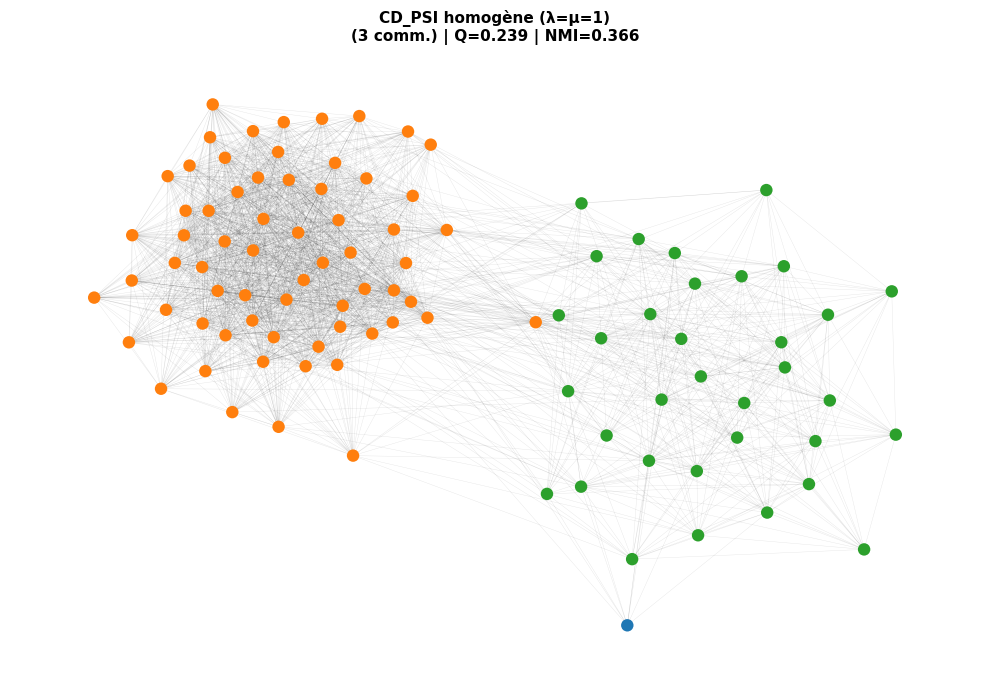

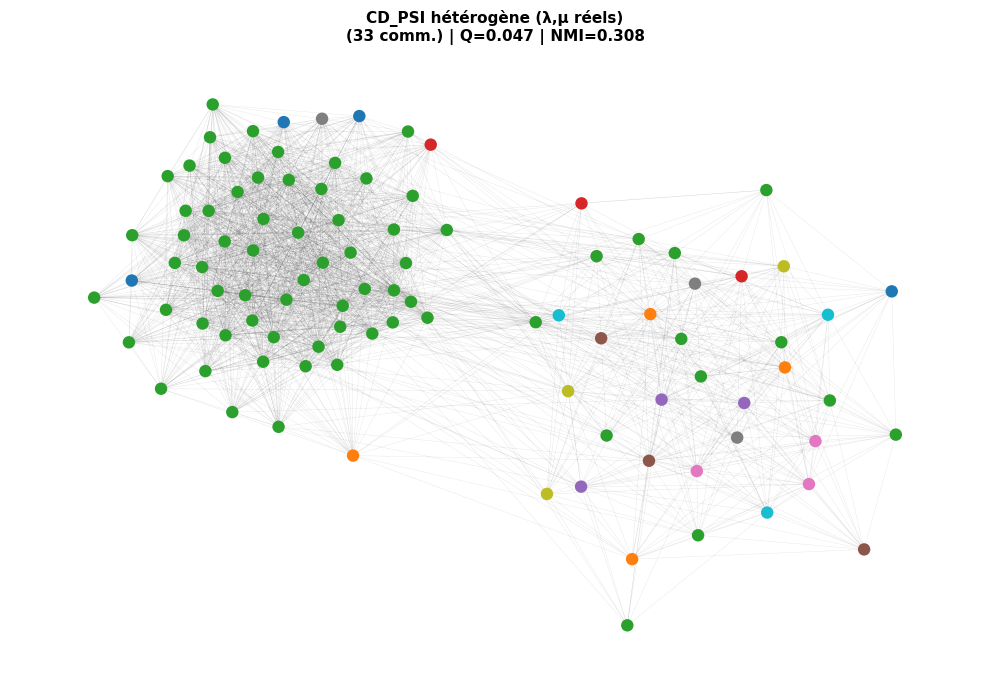

In [39]:
pos = nx.spring_layout(subgraph, seed=42)
palette = plt.cm.tab10.colors

for name, part, pred, filename in [
    ("CD_PSI homogène (λ=μ=1)",       communities_psi, labels_hom, "fig_psi_hom.pdf"),
    ("CD_PSI hétérogène (λ,μ réels)", communities_het, labels_het, "fig_psi_het.pdf"),
]:
    node_colors = [palette[pred[n] % 10] for n in nodes_reindexed]
    nmi = normalized_mutual_info_score(true_opinions, pred)
    Q   = nx_modularity(subgraph, list(part))

    fig, ax = plt.subplots(figsize=(10, 7))
    nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.1, width=0.3)
    nx.draw_networkx_nodes(subgraph, pos, ax=ax,
                           node_color=node_colors,
                           node_size=80, linewidths=0)
    ax.set_title(f"{name}\n({len(part)} comm.) | Q={Q:.3f} | NMI={nmi:.3f}",
                 fontsize=11, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()
